In [320]:
#Step 1 — Import libraries
# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

# Pandas → data handling
import pandas as pd

# NumPy → numerical operations
import numpy as np

# Matplotlib → visualization
import matplotlib.pyplot as plt

# Seaborn → statistical visualization
import seaborn as sns

# Scikit-learn → Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    LabelEncoder,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)


In [321]:
#Step 2 — Load your dataset
# ============================================================
# STEP 2: LOAD DATASET
# ============================================================

# Change the path if your CSV is stored somewhere else
df = pd.read_csv("C:/Users/karun/OneDrive/Desktop/Machine learning/ML Assignment/kidney_dataset.csv")

# Display first 5 rows
df.head()

,Creatinine,BUN,GFR,Urine_Output,Diabetes,Hypertension,Age,Protein_in_Urine,Water_Intake,Medication,CKD_Status
0,0.788803,8.386869,102.161787,1632.649387,0,0,27.682074,106.700203,1.570370,NaN,0
1,3.413970,53.688796,50.071257,935.540516,1,0,33.122208,410.008362,3.425287,ACE Inhibitor,1
2,0.647645,7.466540,89.451831,1774.553846,1,1,55.832284,123.336925,1.123301,Diuretic,0
3,0.795508,12.516821,99.872180,2360.602980,0,0,32.391900,116.098870,3.086846,ACE Inhibitor,0
4,0.869010,19.855960,86.110182,1987.750901,0,1,66.689515,55.668760,2.174980,ARB,0


In [322]:
#Step 3 — Understand the dataset
# ============================================================
# STEP 3: BASIC DATASET INFORMATION
# ============================================================

# Number of rows and columns
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Basic information
print("\nDataset Information:")
df.info()

Shape: (5000, 11)

Columns:
Index(['Creatinine', 'BUN', 'GFR', 'Urine_Output', 'Diabetes', 'Hypertension',
       'Age', 'Protein_in_Urine', 'Water_Intake', 'Medication', 'CKD_Status'],
      dtype='str')

Data Types:
Creatinine          float64
BUN                 float64
GFR                 float64
Urine_Output        float64
Diabetes              int64
Hypertension          int64
Age                 float64
Protein_in_Urine    float64
Water_Intake        float64
Medication              str
CKD_Status            int64
dtype: object

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Creatinine        5000 non-null   float64
 1   BUN               5000 non-null   float64
 2   GFR               5000 non-null   float64
 3   Urine_Output      5000 non-null   float64
 4   Diabetes          5000 non-null   int64  
 5   Hyperten

In [323]:
#Step 4 — Check missing values
# ============================================================
# STEP 4: CHECK MISSING VALUES
# ============================================================

# Count missing values in every column
print(df.isnull().sum())

# Percentage of missing values
missing_percentage = df.isnull().mean() * 100

print("\nMissing Value Percentage:")
print(missing_percentage)

Creatinine             0
BUN                    0
GFR                    0
Urine_Output           0
Diabetes               0
Hypertension           0
Age                    0
Protein_in_Urine       0
Water_Intake           0
Medication          2987
CKD_Status             0
dtype: int64

Missing Value Percentage:
Creatinine           0.00
BUN                  0.00
GFR                  0.00
Urine_Output         0.00
Diabetes             0.00
Hypertension         0.00
Age                  0.00
Protein_in_Urine     0.00
Water_Intake         0.00
Medication          59.74
CKD_Status           0.00
dtype: float64


In [324]:
#Step 5 — Check duplicates
# ============================================================
# STEP 5: CHECK DUPLICATES
# ============================================================

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


CKD_Status
0    3685
1    1315
Name: count, dtype: int64


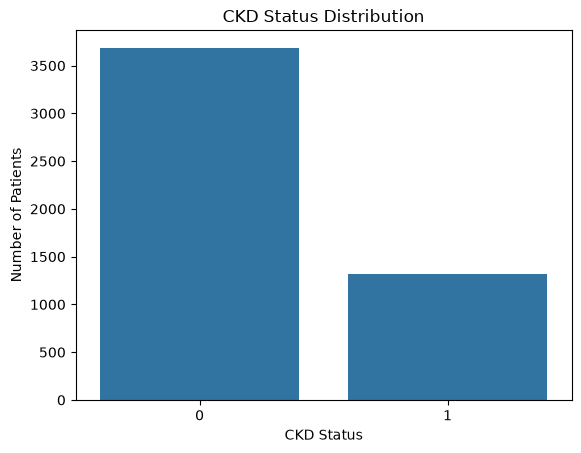

In [325]:
#Step 6 — Check target variable
# ============================================================
# STEP 6: CHECK TARGET VARIABLE
# ============================================================

print(df["CKD_Status"].value_counts())

# Plot target distribution
sns.countplot(data=df, x="CKD_Status")

plt.title("CKD Status Distribution")
plt.xlabel("CKD Status")
plt.ylabel("Number of Patients")

plt.show()

In [326]:
#Step 7 — Separate X and y
# ============================================================
# STEP 7: SEPARATE FEATURES AND TARGET
# ============================================================

# X = input features
X = df.drop("CKD_Status", axis=1)

# y = target/output
y = df["CKD_Status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 10)
y shape: (5000,)


In [327]:
#Step 8 — Identify numerical and categorical columns
# ============================================================
# STEP 8: IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

# Numerical columns
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Categorical columns
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Creatinine', 'BUN', 'GFR', 'Urine_Output', 'Diabetes', 'Hypertension', 'Age', 'Protein_in_Urine', 'Water_Intake']

Categorical Features:
['Medication']


C:\Users\karun\AppData\Local\Temp\ipykernel_17672\2982283099.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [328]:
#Step 9 — Encode the categorical variable
# ============================================================
# STEP 9: PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        
        # Scale numerical features
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        
        # Convert categorical features into numerical values
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [329]:
#Step 10 — Train-test split
# ============================================================
# STEP 10: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    
    # 80% training, 20% testing
    test_size=0.20,
    
    # Same split every time
    random_state=42,
    
    # Maintain class proportions
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 10)
Testing data: (1000, 10)


In [330]:
#Step 11 — Logistic Regression
# ============================================================
# STEP 11: LOGISTIC REGRESSION
# ============================================================

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train
logistic_pipeline.fit(X_train, y_train)

# Predict
y_pred_logistic = logistic_pipeline.predict(X_test)

# Accuracy
print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test, y_pred_logistic)
)

# Detailed report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

Logistic Regression Accuracy: 0.996

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       737
           1       0.99      1.00      0.99       263

    accuracy                           1.00      1000
   macro avg       0.99      1.00      0.99      1000
weighted avg       1.00      1.00      1.00      1000



In [331]:
#Step 12 — KNN
# ============================================================
# STEP 12: K-NEAREST NEIGHBORS
# ============================================================

knn_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        
        ("model", KNeighborsClassifier(
            n_neighbors=5,
            weights="uniform",
            metric="minkowski"
        ))
    ]
)

# Train
knn_pipeline.fit(X_train, y_train)

# Predict
y_pred_knn = knn_pipeline.predict(X_test)

# Accuracy
print(
    "KNN Accuracy:",
    accuracy_score(y_test, y_pred_knn)
)

# Classification report
print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

KNN Accuracy: 0.985
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       737
           1       0.95      0.99      0.97       263

    accuracy                           0.98      1000
   macro avg       0.97      0.99      0.98      1000
weighted avg       0.99      0.98      0.99      1000



In [332]:
#Step 13 — Decision Tree
# ============================================================
# STEP 13: DECISION TREE
# ============================================================

dt_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        
        ("model", DecisionTreeClassifier(
            criterion="gini",
            max_depth=5,
            min_samples_split=2,
            random_state=42
        ))
    ]
)

# Train
dt_pipeline.fit(X_train, y_train)

# Predict
y_pred_dt = dt_pipeline.predict(X_test)

print(
    "Decision Tree Accuracy:",
    accuracy_score(y_test, y_pred_dt)
)

print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       737
           1       1.00      1.00      1.00       263

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [333]:
#Step 14 — Random Forest
# ============================================================
# STEP 14: RANDOM FOREST
# ============================================================

rf_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        
        ("model", RandomForestClassifier(
            n_estimators=100,
            criterion="gini",
            max_depth=None,
            min_samples_split=2,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train
rf_pipeline.fit(X_train, y_train)

# Predict
y_pred_rf = rf_pipeline.predict(X_test)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       737
           1       1.00      1.00      1.00       263

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [334]:
#Step 15 — SVM
# ============================================================
# STEP 15: SUPPORT VECTOR MACHINE
# ============================================================

svm_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        
        ("model", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            random_state=42
        ))
    ]
)

# Train
svm_pipeline.fit(X_train, y_train)

# Predict
y_pred_svm = svm_pipeline.predict(X_test)

print(
    "SVM Accuracy:",
    accuracy_score(y_test, y_pred_svm)
)

print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

SVM Accuracy: 0.996
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       737
           1       0.99      1.00      0.99       263

    accuracy                           1.00      1000
   macro avg       0.99      1.00      0.99      1000
weighted avg       1.00      1.00      1.00      1000



c:\Users\karun\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [335]:
#Step 16 — Naive Bayes
# ============================================================
# STEP 16: NAIVE BAYES
# ============================================================

# Fit preprocessing separately
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrix to dense array if necessary
X_train_processed = X_train_processed.toarray() \
    if hasattr(X_train_processed, "toarray") \
    else X_train_processed

X_test_processed = X_test_processed.toarray() \
    if hasattr(X_test_processed, "toarray") \
    else X_test_processed

# Create model
nb_model = GaussianNB()

# Train
nb_model.fit(
    X_train_processed,
    y_train
)

# Predict
y_pred_nb = nb_model.predict(
    X_test_processed
)

print(
    "Naive Bayes Accuracy:",
    accuracy_score(y_test, y_pred_nb)
)

print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

Naive Bayes Accuracy: 0.981
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       737
           1       0.93      1.00      0.97       263

    accuracy                           0.98      1000
   macro avg       0.97      0.99      0.98      1000
weighted avg       0.98      0.98      0.98      1000



In [336]:
#Step 17 — Gradient Boosting
# ============================================================
# STEP 17: GRADIENT BOOSTING
# ============================================================

gb_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        
        ("model", GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ))
    ]
)

# Train
gb_pipeline.fit(X_train, y_train)

# Predict
y_pred_gb = gb_pipeline.predict(X_test)

print(
    "Gradient Boosting Accuracy:",
    accuracy_score(y_test, y_pred_gb)
)

print(
    classification_report(
        y_test,
        y_pred_gb
    )
)

Gradient Boosting Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       737
           1       1.00      1.00      1.00       263

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [337]:
#Step 18 — Compare all models
# ============================================================
# STEP 18: MODEL COMPARISON
# ============================================================

models = {
    "Logistic Regression": y_pred_logistic,
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "Naive Bayes": y_pred_nb,
    "Gradient Boosting": y_pred_gb
}

results = []

for model_name, predictions in models.items():

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Decision Tree,1.000,1.000000,1.000,1.000000
6,Gradient Boosting,1.000,1.000000,1.000,1.000000
3,Random Forest,1.000,1.000000,1.000,1.000000
4,SVM,0.996,0.996060,0.996,0.996010
0,Logistic Regression,0.996,0.996060,0.996,0.996010
1,KNN,0.985,0.985492,0.985,0.985097
5,Naive Bayes,0.981,0.982280,0.981,0.981207


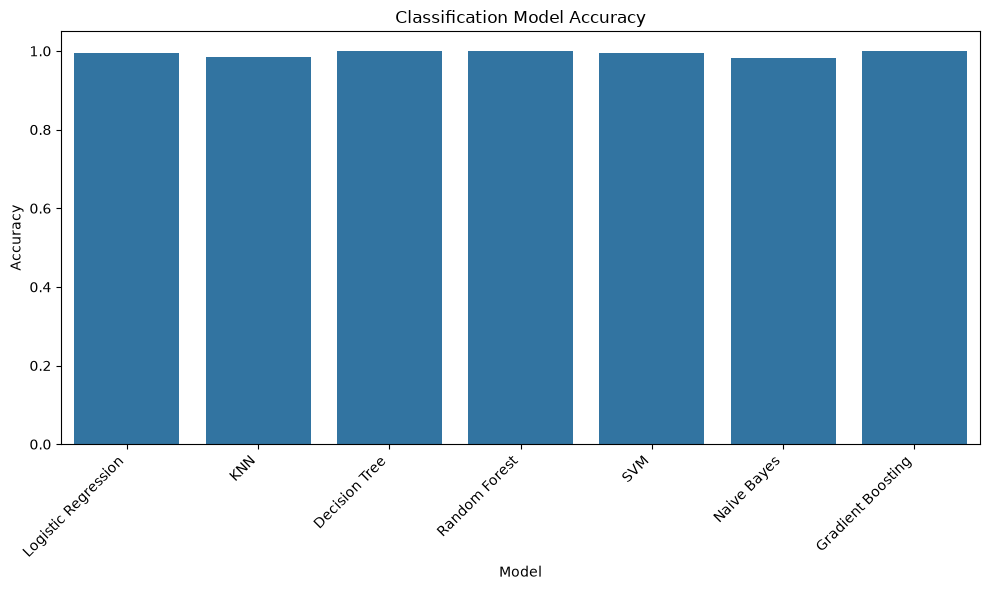

In [338]:
#Step 19 — Visualize model performance
# ============================================================
# STEP 19: MODEL PERFORMANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.title("Classification Model Accuracy")

plt.tight_layout()

plt.show()

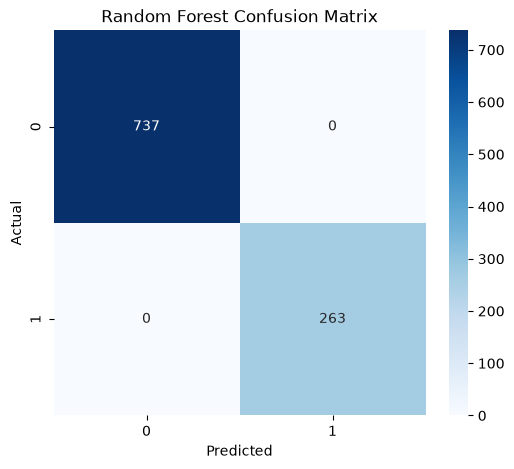

In [339]:
#Step 20 — Confusion Matrix
# ============================================================
# STEP 20: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [340]:
#Step 21 — Cross-validation
# ============================================================
# STEP 21: CROSS VALIDATION
# ============================================================

cv_scores = cross_val_score(
    logistic_pipeline,
    X,
    y,
    
    # 5-fold cross validation
    cv=5,
    
    # Evaluation metric
    scoring="accuracy"
)

print("Cross-validation scores:")
print(cv_scores)

print("\nMean CV Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Cross-validation scores:
[0.998 0.999 1.    0.999 0.996]

Mean CV Accuracy:
0.9984

Standard Deviation:
0.001356465996625055


In [341]:
#Step 22 — Hyperparameter tuning with GridSearchCV
# ============================================================
# STEP 22: RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

rf_grid_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        
        ("model", RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Parameters to test
param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    rf_grid_pipeline,
    param_grid=param_grid,
    
    # 5-fold CV
    cv=5,
    
    # Evaluation metric
    scoring="accuracy",
    
    # Use all CPU cores
    n_jobs=-1
)

# Train GridSearchCV
grid_search.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 50}

Best CV Score:
0.99975


In [342]:
#Step 23 — Test the tuned model
# ============================================================
# STEP 23: EVALUATE BEST MODEL
# ============================================================

best_model = grid_search.best_estimator_

# Predictions
y_pred_best = best_model.predict(X_test)

# Accuracy
print(
    "Test Accuracy:",
    accuracy_score(
        y_test,
        y_pred_best
    )
)

# Complete report
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_best
    )
)

Test Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       737
           1       1.00      1.00      1.00       263

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [343]:
#Step 24 — ROC-AUC
# ============================================================
# STEP 24: ROC-AUC
# ============================================================

# Get probability of positive class
y_probability = best_model.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 1.0


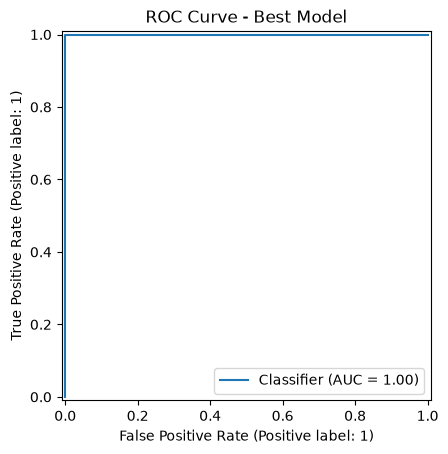

In [344]:
# ============================================================
# STEP 25: ROC CURVE
# ============================================================

RocCurveDisplay.from_predictions(
    y_test,
    y_probability
)

plt.title("ROC Curve - Best Model")

plt.show()